<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/ensemble_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_excel('https://github.com/gurudattamanpreet/datasets/raw/main/Tourism.xlsx', sheet_name='Tourism')

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [4]:
df.shape

(4888, 20)

In [5]:
df.select_dtypes(include=['object']).nunique()

,0
TypeofContact,2
Occupation,4
Gender,3
ProductPitched,5
MaritalStatus,4
Designation,5


In [6]:
q=df.select_dtypes(include=['object']).columns.tolist()

In [7]:
for i in q:
  print(df[i].value_counts(),'\n')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64 

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64 

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64 

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64 

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64 

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64 



In [8]:
df['Gender']=df['Gender'].str.replace('Fe Male','Female')

In [9]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1972


In [10]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
CustomerID,4888
ProdTaken,2
Age,44
CityTier,3
DurationOfPitch,34
NumberOfPersonVisiting,5
NumberOfFollowups,6
PreferredPropertyStar,3
NumberOfTrips,12
Passport,2


In [11]:
df.drop(['CustomerID'],axis=1,inplace=True)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ProdTaken,4888.0,0.188216,0.390925,0.0,0.0,0.0,0.0,1.0
Age,4662.0,37.622265,9.316387,18.0,31.0,36.0,44.0,61.0
CityTier,4888.0,1.654255,0.916583,1.0,1.0,1.0,3.0,3.0
DurationOfPitch,4637.0,15.490835,8.519643,5.0,9.0,13.0,20.0,127.0
NumberOfPersonVisiting,4888.0,2.905074,0.724891,1.0,2.0,3.0,3.0,5.0
NumberOfFollowups,4843.0,3.708445,1.002509,1.0,3.0,4.0,4.0,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.0,3.0,4.0,5.0
NumberOfTrips,4748.0,3.236521,1.849019,1.0,2.0,3.0,4.0,22.0
Passport,4888.0,0.290917,0.454232,0.0,0.0,0.0,1.0,1.0
PitchSatisfactionScore,4888.0,3.078151,1.365792,1.0,2.0,3.0,4.0,5.0


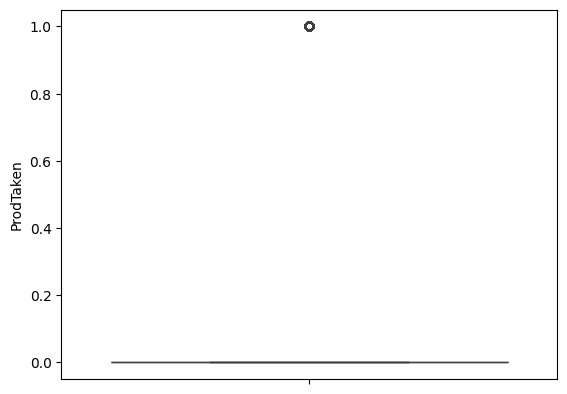

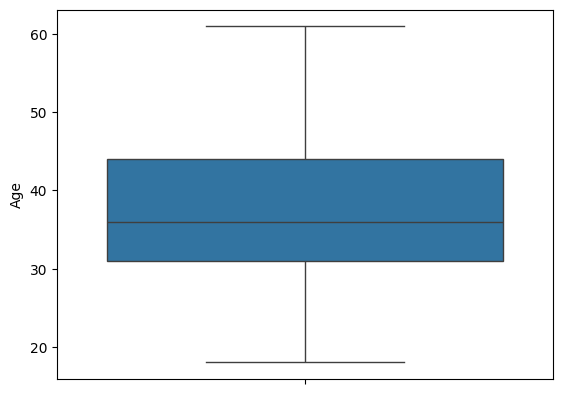

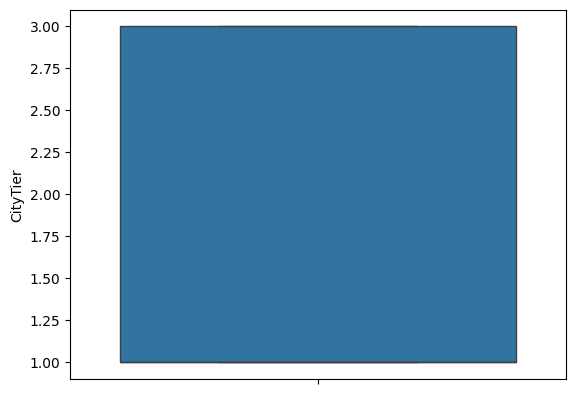

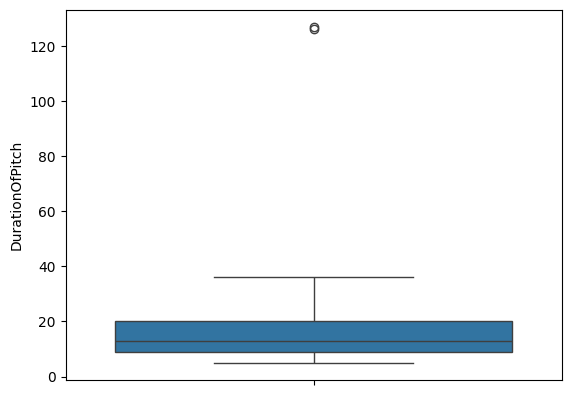

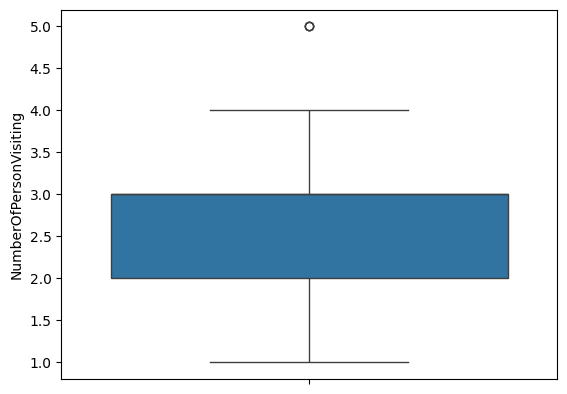

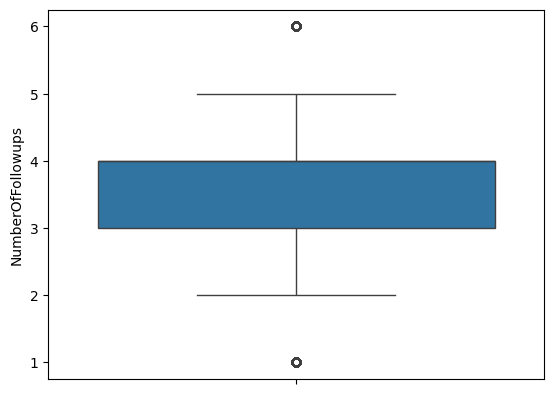

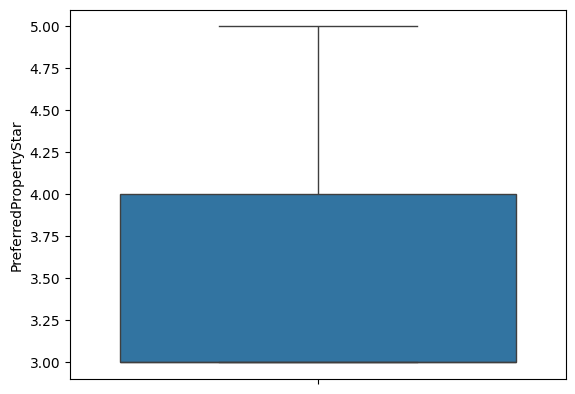

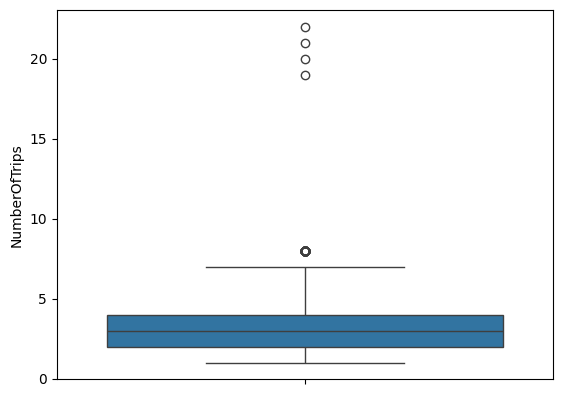

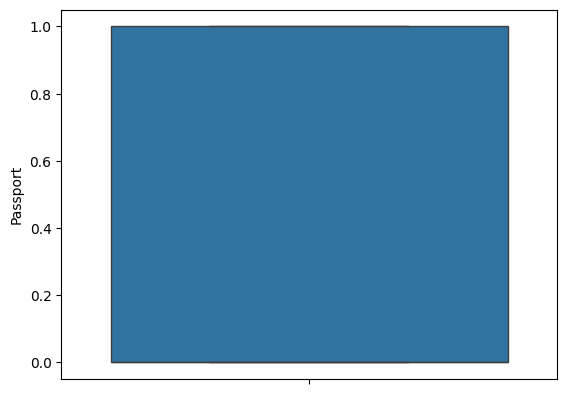

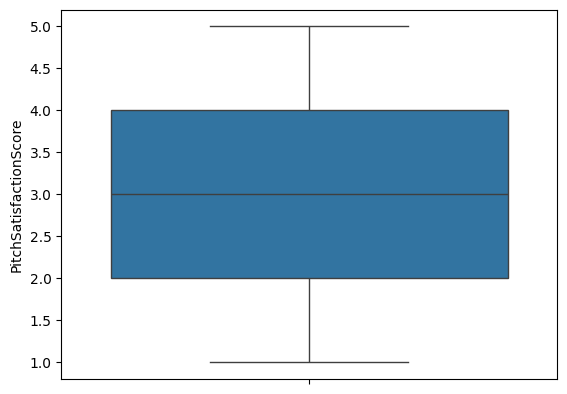

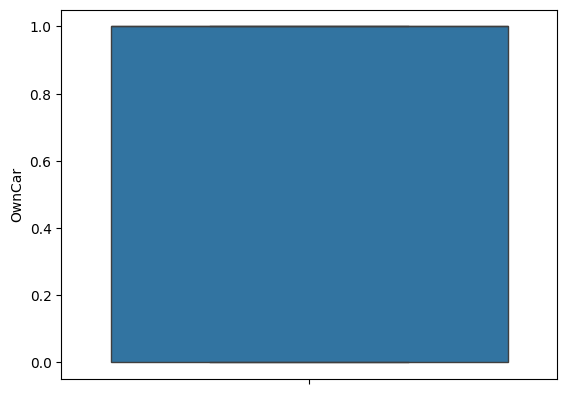

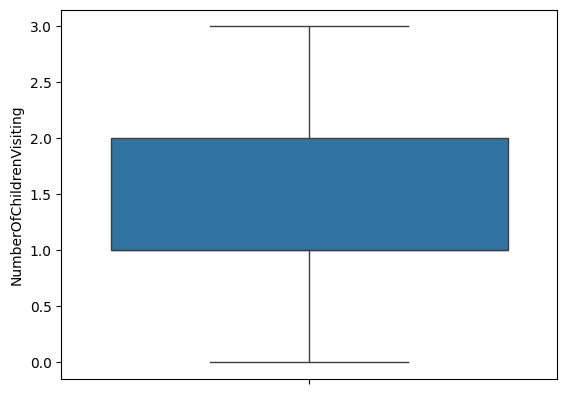

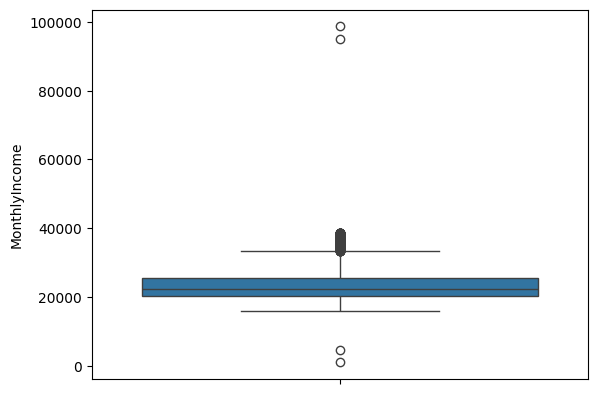

In [13]:
w=df.select_dtypes(include=['int64','float64']).columns.tolist()
for i in w:
  sns.boxplot(df[i])
  plt.show()

In [14]:
df['NumberOfChildrenVisiting'].value_counts()

,count
NumberOfChildrenVisiting,
1.0,2080
2.0,1335
0.0,1082
3.0,325


In [15]:
df['NumberOfTrips'].value_counts()

,count
NumberOfTrips,
2.0,1464
3.0,1079
1.0,620
4.0,478
5.0,458
6.0,322
7.0,218
8.0,105
19.0,1


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

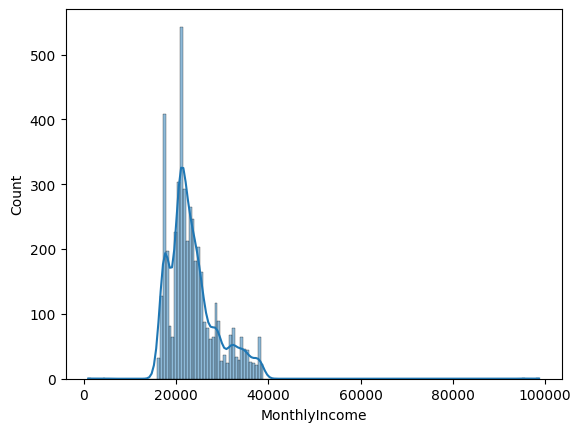

In [16]:
sns.histplot(df['MonthlyIncome'],kde=True)

In [17]:
df.dtypes

,0
ProdTaken,int64
Age,float64
TypeofContact,object
CityTier,int64
DurationOfPitch,float64
Occupation,object
Gender,object
NumberOfPersonVisiting,int64
NumberOfFollowups,float64
ProductPitched,object


      1. Handle missing values
          - Numeric: median/mean
          - Categorical: mode

      2. Handle outliers
          - Only for numeric columns (after NaN fill)

      3. Encode categorical features
          - LabelEncoding (for tree models)
          - OneHotEncoding (for linear models)

      4. Scale numeric features (if needed)

    Ideal preprocessing sequence:

    Train-Test Split
    Missing Value Treatment
    Outlier Treatment
    Categorical Encoding (One-Hot/Label)
    Feature Scaling/Transformation

    Step 1: Train-Test Split
         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


            
    Step 2: Missing Value Treatment (using train parameters)
            # For numerical columns
            imputer = SimpleImputer(strategy='mean')
            imputer.fit(X_train_encoded[num_cols])  # Learn from training data
            
            X_train_imputed = imputer.transform(X_train_encoded)
            X_test_imputed = imputer.transform(X_test_encoded)
            
    Step 3: Outlier Treatment (using train parameters)
            # Define thresholds from training data
            # Apply same thresholds to test data

    Step 4: Categorical Encoding (with full dataset perspective)
            # Option 1: OneHotEncoder
            encoder = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
            encoder.fit(X_train[cat_cols])  # Learn from training data only
            
            X_train_encoded = transform and combine with numerical columns
            X_test_encoded = transform and combine with numerical columns
            
    Step 5: Feature Scaling/Transformation (using train parameters)
            scaler = StandardScaler()
            scaler.fit(X_train_imputed)  # Learn from training data
            
            X_train_scaled = scaler.transform(X_train_imputed)
            X_test_scaled = scaler.transform(X_test_imputed)

    1. Train-test split (real-world simulation)
    2. Sirf train pe:
      - Missing value treatment
      - Outlier treatment
      - Encoding
      - Imbalance treatment (SMOTE etc.)
    3. Test data untouched rehta hai — sirf transform hota hai

    •	Model sirf training data se seekhta hai
    •	Test data true unknown ki tarah rehta hai
    •	Results real-world me trustworthy hote hain

    | Tumhara pehle ka approach                      | Galat?              | Safe for deployment? | Conceptually OK? |
    | ---------------------------------------------- | ------------------- | -------------------- | ---------------- |
    | Cleaning + SMOTE before split                  | ❌ Not best practice | ❌ No                 | ✔️ For learning  |
    | Train-test split first, then all preprocessing | ✅ Yes               | ✅ Yes                | ✅ Perfect        |


In [18]:
X=df.drop(['ProdTaken'],axis=1)
y=df[['ProdTaken']]

In [19]:
y.value_counts()

,count
ProdTaken,
0,3968
1,920


In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [21]:
X_train.select_dtypes(include=['int64','float64']).isna().sum()

,0
Age,180
CityTier,0
DurationOfPitch,205
NumberOfPersonVisiting,0
NumberOfFollowups,37
PreferredPropertyStar,22
NumberOfTrips,112
Passport,0
PitchSatisfactionScore,0
OwnCar,0


In [22]:
X_test.shape

(978, 18)

In [23]:
X_train.select_dtypes(include=['object']).nunique()

,0
TypeofContact,2
Occupation,4
Gender,2
ProductPitched,5
MaritalStatus,4
Designation,5


In [24]:
d=['Age','DurationOfPitch','NumberOfFollowups','PreferredPropertyStar','NumberOfTrips','NumberOfChildrenVisiting','MonthlyIncome']
si1=SimpleImputer(strategy='median')
X_train[d]=si1.fit_transform(X_train[d])
X_test[d]=si1.transform(X_test[d])

In [25]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [26]:
e=['TypeofContact']
si2=SimpleImputer(strategy='most_frequent')
X_train[e]=si2.fit_transform(X_train[e])
X_test[e]=si2.transform(X_test[e])

In [27]:
# Step 1: Identify categorical columns
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

# Step 2: Initialize OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Step 3: Fit encoder on training data
encoder.fit(X_train[cat_cols])

# Step 4: Transform train and test categorical features
train_encoded = encoder.transform(X_train[cat_cols])
test_encoded = encoder.transform(X_test[cat_cols])

# Step 5: Convert encoded arrays into DataFrames with proper index
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

# Step 6: Concatenate encoded categorical + numerical features
X_train_processed = pd.concat([X_train[num_cols], train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test[num_cols], test_encoded_df], axis=1)

# Optional: Safety check
assert X_train_processed.shape[1] == X_test_processed.shape[1], "Column mismatch between train and test!"

In [28]:
smote = SMOTE(random_state=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

In [29]:
X_train_balanced.shape

(6370, 28)

In [30]:
X_test.shape

(978, 18)

In [31]:
y_train_balanced.shape

(6370, 1)

In [32]:
y_test.shape

(978, 1)